# 🗢️ Programação em Banco de Dados

`Banco de Dados` · **8º semestre · Engenharia da Computação** · `Python 3`

> **SQL básico, joins, agregação, views, procedures, transações e índices.**

Programação com bancos de dados relacionais: DDL, DML, JOINs, agregações, transações ACID, índices e procedures — tudo executado em SQLite.


## 🖼️ Resultado visual

Este é o **cheat sheet** da matéria, gerado pelo código abaixo (a mesma lógica é reutilizada na célula de geração do PDF). As páginas são renderizadas automaticamente.


PDF gerado em Programacao_Banco_de_Dados.pdf
Páginas: 1


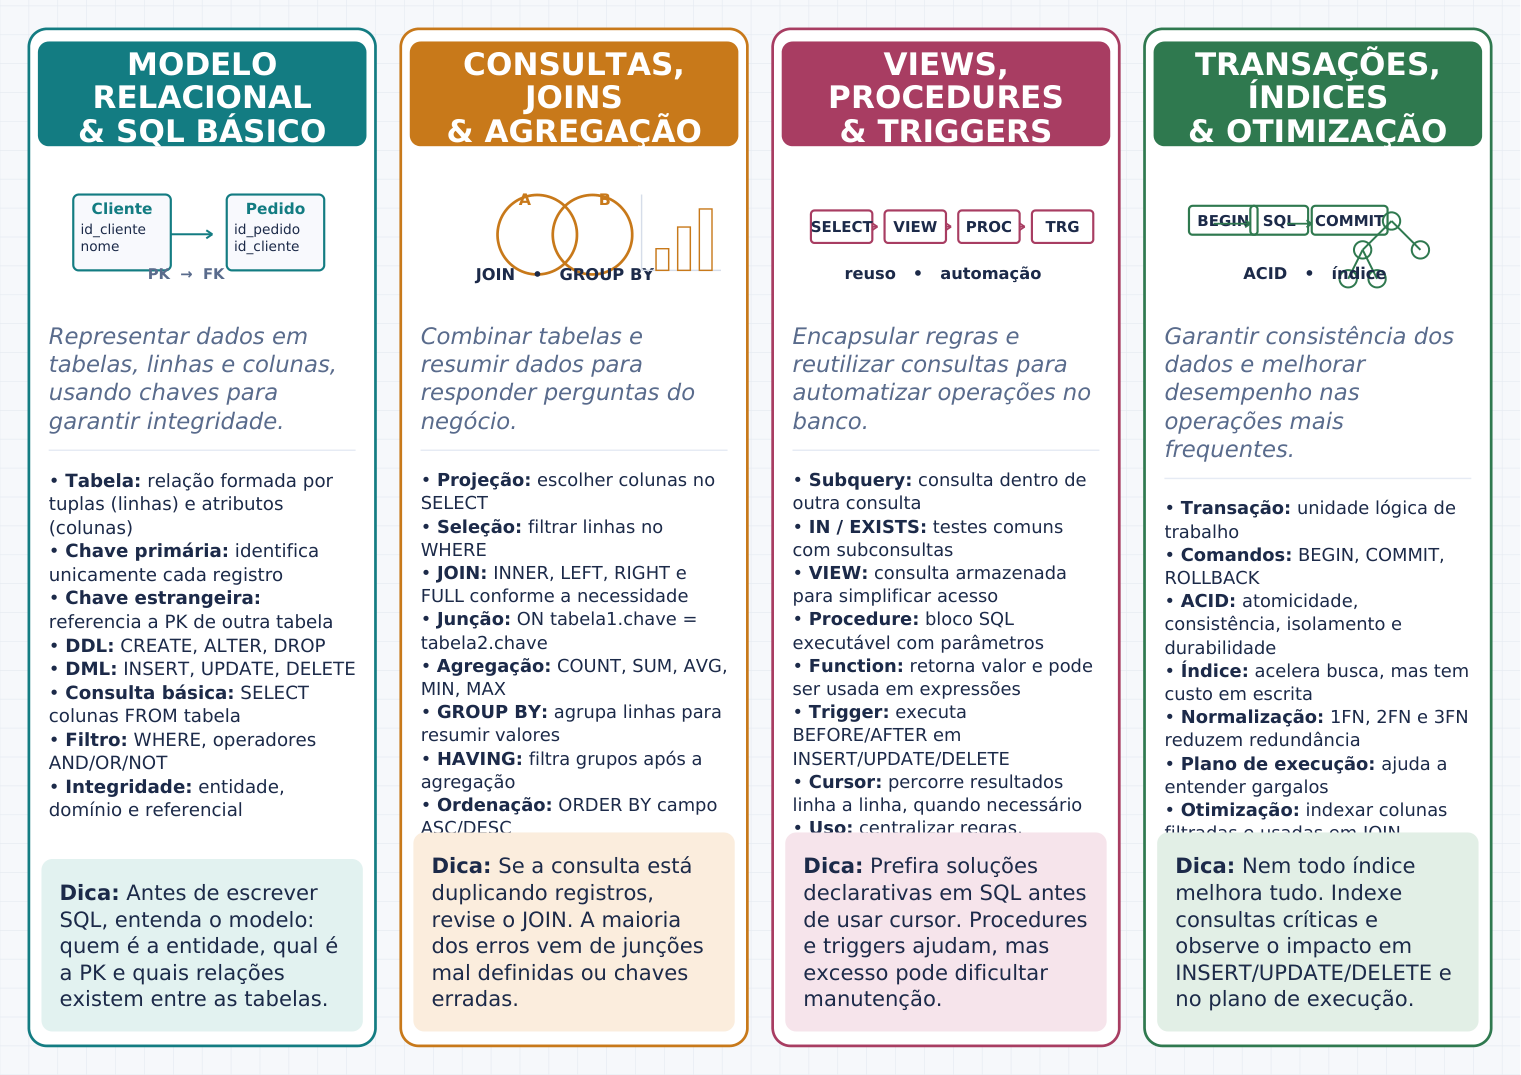

In [1]:
from pathlib import Path
import matplotlib as _mpl

def _dejavu_dir():
    _base = Path(_mpl.__file__).parent / "mpl-data" / "fonts" / "ttf"
    if (_base / "DejaVuSans.ttf").exists():
        return str(_base)
    for _p in [Path("/usr/share/fonts/truetype/dejavu"),
               Path("/System/Library/Fonts"),
               Path("/Library/Fonts"),
               Path("C:/Windows/Fonts")]:
        if (_p / "DejaVuSans.ttf").exists():
            return str(_p)
    raise RuntimeError("Fonte DejaVuSans nao encontrada; instale matplotlib ou a fonte DejaVu.")


# ===== código original adaptado =====
import math
from pathlib import Path

from reportlab.lib.colors import HexColor
from reportlab.lib.pagesizes import A4, landscape
from reportlab.lib.styles import ParagraphStyle
from reportlab.pdfbase import pdfmetrics
from reportlab.pdfbase.ttfonts import TTFont
from reportlab.pdfgen import canvas
from reportlab.platypus import Paragraph

OUT = Path('Programacao_Banco_de_Dados.pdf')
PREVIEW = Path('/mnt/data/Programacao_Banco_de_Dados_OneNote_preview.png')
PAGE_W, PAGE_H = landscape(A4)
MARGIN = 16

# ---------- fonts ----------
FONT_DIR = Path(_dejavu_dir())
pdfmetrics.registerFont(TTFont('DVCond', str(FONT_DIR / 'DejaVuSans.ttf')))
pdfmetrics.registerFont(TTFont('DVCond-Bold', str(FONT_DIR / 'DejaVuSans-Bold.ttf')))
pdfmetrics.registerFont(TTFont('DVCond-Oblique', str(FONT_DIR / 'DejaVuSans-Oblique.ttf')))
pdfmetrics.registerFontFamily(
    'DVCond',
    normal='DVCond',
    bold='DVCond-Bold',
    italic='DVCond-Oblique',
    boldItalic='DVCond-Bold',
)

# ---------- palette ----------
BG = HexColor('#F6F8FB')
GRID = HexColor('#E6EBF3')
INK = HexColor('#1C2B4A')
MUTED = HexColor('#5A6B8C')
WHITE = HexColor('#FFFFFF')
LINE = HexColor('#E7ECF4')
AXIS = HexColor('#D7DEEA')

TEAL, TEAL_T = HexColor('#147D82'), HexColor('#E3F2F1')
AMBER, AMBER_T = HexColor('#C97A1A'), HexColor('#FBEDDD')
BERRY, BERRY_T = HexColor('#A83E63'), HexColor('#F6E4EB')
GREEN, GREEN_T = HexColor('#2F7A4F'), HexColor('#E2F0E7')

CARDS = [
    {
        'title': 'MODELO RELACIONAL<br/>&amp; SQL BÁSICO',
        'color': TEAL,
        'tint': TEAL_T,
        'kind': 'modelo',
        'idea': 'Representar dados em tabelas, linhas e colunas, usando chaves para garantir integridade.',
        'formulas': [
            '<b>Tabela:</b> relação formada por tuplas (linhas) e atributos (colunas)',
            '<b>Chave primária:</b> identifica unicamente cada registro',
            '<b>Chave estrangeira:</b> referencia a PK de outra tabela',
            '<b>DDL:</b> CREATE, ALTER, DROP',
            '<b>DML:</b> INSERT, UPDATE, DELETE',
            '<b>Consulta básica:</b> SELECT colunas FROM tabela',
            '<b>Filtro:</b> WHERE, operadores AND/OR/NOT',
            '<b>Integridade:</b> entidade, domínio e referencial',
        ],
        'tip': 'Antes de escrever SQL, entenda o modelo: quem é a entidade, qual é a PK e quais relações existem entre as tabelas.',
    },
    {
        'title': 'CONSULTAS, JOINS<br/>&amp; AGREGAÇÃO',
        'color': AMBER,
        'tint': AMBER_T,
        'kind': 'consultas',
        'idea': 'Combinar tabelas e resumir dados para responder perguntas do negócio.',
        'formulas': [
            '<b>Projeção:</b> escolher colunas no SELECT',
            '<b>Seleção:</b> filtrar linhas no WHERE',
            '<b>JOIN:</b> INNER, LEFT, RIGHT e FULL conforme a necessidade',
            '<b>Junção:</b> ON tabela1.chave = tabela2.chave',
            '<b>Agregação:</b> COUNT, SUM, AVG, MIN, MAX',
            '<b>GROUP BY:</b> agrupa linhas para resumir valores',
            '<b>HAVING:</b> filtra grupos após a agregação',
            '<b>Ordenação:</b> ORDER BY campo ASC/DESC',
        ],
        'tip': 'Se a consulta está duplicando registros, revise o JOIN. A maioria dos erros vem de junções mal definidas ou chaves erradas.',
    },
    {
        'title': 'VIEWS, PROCEDURES<br/>&amp; TRIGGERS',
        'color': BERRY,
        'tint': BERRY_T,
        'kind': 'programacao',
        'idea': 'Encapsular regras e reutilizar consultas para automatizar operações no banco.',
        'formulas': [
            '<b>Subquery:</b> consulta dentro de outra consulta',
            '<b>IN / EXISTS:</b> testes comuns com subconsultas',
            '<b>VIEW:</b> consulta armazenada para simplificar acesso',
            '<b>Procedure:</b> bloco SQL executável com parâmetros',
            '<b>Function:</b> retorna valor e pode ser usada em expressões',
            '<b>Trigger:</b> executa BEFORE/AFTER em INSERT/UPDATE/DELETE',
            '<b>Cursor:</b> percorre resultados linha a linha, quando necessário',
            '<b>Uso:</b> centralizar regras, auditoria e automações',
        ],
        'tip': 'Prefira soluções declarativas em SQL antes de usar cursor. Procedures e triggers ajudam, mas excesso pode dificultar manutenção.',
    },
    {
        'title': 'TRANSAÇÕES, ÍNDICES<br/>&amp; OTIMIZAÇÃO',
        'color': GREEN,
        'tint': GREEN_T,
        'kind': 'otimizacao',
        'idea': 'Garantir consistência dos dados e melhorar desempenho nas operações mais frequentes.',
        'formulas': [
            '<b>Transação:</b> unidade lógica de trabalho',
            '<b>Comandos:</b> BEGIN, COMMIT, ROLLBACK',
            '<b>ACID:</b> atomicidade, consistência, isolamento e durabilidade',
            '<b>Índice:</b> acelera busca, mas tem custo em escrita',
            '<b>Normalização:</b> 1FN, 2FN e 3FN reduzem redundância',
            '<b>Plano de execução:</b> ajuda a entender gargalos',
            '<b>Otimização:</b> indexar colunas filtradas e usadas em JOIN',
            '<b>Boas práticas:</b> evitar SELECT *, revisar locks e volume',
        ],
        'tip': 'Nem todo índice melhora tudo. Indexe consultas críticas e observe o impacto em INSERT/UPDATE/DELETE e no plano de execução.',
    },
]

# ---------- layout ----------
CARD_TOP = PAGE_H - 16
CARD_BOTTOM = 16
CARD_H = CARD_TOP - CARD_BOTTOM
GAP = 14
CARD_W = (PAGE_W - 2 * MARGIN - 3 * GAP) / 4

STYLE_TITLE = ParagraphStyle(
    'card_title',
    fontName='DVCond-Bold',
    fontSize=17.2,
    leading=18.6,
    textColor=WHITE,
    alignment=1,
    spaceAfter=0,
)
STYLE_IDEA = ParagraphStyle(
    'idea',
    fontName='DVCond-Oblique',
    fontSize=12.6,
    leading=15.6,
    textColor=MUTED,
)
STYLE_TIP = ParagraphStyle(
    'tip',
    fontName='DVCond',
    fontSize=11.7,
    leading=14.7,
    textColor=INK,
)


def arrow(c, x1, y1, x2, y2, color, width=1.2, head=5):
    c.setStrokeColor(color)
    c.setFillColor(color)
    c.setLineWidth(width)
    c.line(x1, y1, x2, y2)
    ang = math.atan2(y2 - y1, x2 - x1)
    for delta in (2.55, -2.55):
        c.line(x2, y2, x2 + head * math.cos(ang + delta), y2 + head * math.sin(ang + delta))


def box(c, x, y, w, h, color, label=None, fill=False):
    c.setStrokeColor(color)
    c.setFillColor(HexColor('#F8FAFD') if fill else WHITE)
    c.setLineWidth(1.2)
    c.roundRect(x, y, w, h, 2, stroke=1, fill=1 if fill else 0)
    if label:
        c.setFillColor(INK)
        c.setFont('DVCond-Bold', 8.3)
        c.drawCentredString(x + w/2, y + h/2 - 3, label)


def diagram_modelo(c, ox, oy, dw, dh, color):
    # two related tables
    left_x, left_y = ox + dw*0.08, oy + dh*0.24
    right_x, right_y = ox + dw*0.58, oy + dh*0.24
    for x,y,title in [(left_x,left_y,'Cliente'), (right_x,right_y,'Pedido')]:
        c.setStrokeColor(color)
        c.setFillColor(HexColor('#F8FAFD'))
        c.setLineWidth(1.2)
        c.roundRect(x, y, 54, 42, 3, fill=1, stroke=1)
        c.setFillColor(color)
        c.setFont('DVCond-Bold', 8.5)
        c.drawCentredString(x+27, y+31, title)
        c.setFillColor(INK)
        c.setFont('DVCond', 7.6)
        if title == 'Cliente':
            c.drawString(x+4, y+20, 'id_cliente')
            c.drawString(x+4, y+11, 'nome')
        else:
            c.drawString(x+4, y+20, 'id_pedido')
            c.drawString(x+4, y+11, 'id_cliente')
    arrow(c, left_x+54, left_y+20, right_x-8, right_y+20, color, 1.1, 4)
    c.setFillColor(MUTED)
    c.setFont('DVCond-Bold', 8.2)
    c.drawCentredString((left_x+right_x)/2 + 20, oy + dh*0.18, 'PK  →  FK')


def diagram_consultas(c, ox, oy, dw, dh, color):
    # Venn-like join diagram simplified
    c.setStrokeColor(color)
    c.setLineWidth(1.5)
    c.circle(ox + dw*0.38, oy + dh*0.50, 22, stroke=1, fill=0)
    c.circle(ox + dw*0.56, oy + dh*0.50, 22, stroke=1, fill=0)
    c.setFillColor(color)
    c.setFont('DVCond-Bold', 8.8)
    c.drawCentredString(ox + dw*0.34, oy + dh*0.72, 'A')
    c.drawCentredString(ox + dw*0.60, oy + dh*0.72, 'B')
    c.setFillColor(INK)
    c.setFont('DVCond-Bold', 9.0)
    c.drawCentredString(ox + dw*0.47, oy + dh*0.17, 'JOIN   •   GROUP BY')
    # small bars for aggregation
    base_x, base_y = ox + dw*0.72, oy + dh*0.24
    c.setStrokeColor(AXIS)
    c.setLineWidth(0.8)
    c.line(base_x, base_y, base_x, base_y+42)
    c.line(base_x, base_y, base_x+44, base_y)
    c.setStrokeColor(color)
    for i,h in enumerate([12, 24, 34]):
        c.setFillColor(color)
        c.rect(base_x + 8 + i*12, base_y, 7, h, fill=0, stroke=1)


def diagram_programacao(c, ox, oy, dw, dh, color):
    # flow blocks: query -> view -> procedure -> trigger
    xs = [ox + dw*0.06, ox + dw*0.30, ox + dw*0.54, ox + dw*0.78]
    labels = ['SELECT', 'VIEW', 'PROC', 'TRG']
    y = oy + dh*0.44
    for x,lab in zip(xs, labels):
        box(c, x, y, 34, 18, color, lab)
    for i in range(3):
        arrow(c, xs[i]+34, y+9, xs[i+1]-4, y+9, color, 1.0, 3.5)
    c.setFillColor(INK)
    c.setFont('DVCond-Bold', 9)
    c.drawCentredString(ox + dw*0.49, oy + dh*0.18, 'reuso   •   automação')


def diagram_otimizacao(c, ox, oy, dw, dh, color):
    # transaction flow
    box(c, ox + dw*0.08, oy + dh*0.50, 38, 16, color, 'BEGIN')
    box(c, ox + dw*0.28, oy + dh*0.50, 32, 16, color, 'SQL')
    box(c, ox + dw*0.48, oy + dh*0.50, 42, 16, color, 'COMMIT')
    for x1,x2 in [(ox + dw*0.16, ox + dw*0.28), (ox + dw*0.40, ox + dw*0.48)]:
        arrow(c, x1, oy + dh*0.58, x2, oy + dh*0.58, color, 1.0, 3.5)
    # index tree
    cx, cy = ox + dw*0.74, oy + dh*0.60
    pts = [(cx, cy), (cx-16, cy-16), (cx+16, cy-16), (cx-24, cy-32), (cx-8, cy-32)]
    c.setStrokeColor(color)
    c.setLineWidth(1.1)
    for a,b in [(0,1),(0,2),(1,3),(1,4)]:
        c.line(pts[a][0], pts[a][1], pts[b][0], pts[b][1])
    for x,y in pts:
        c.circle(x, y, 4.8, stroke=1, fill=0)
    c.setFillColor(INK)
    c.setFont('DVCond-Bold', 9.0)
    c.drawCentredString(ox + dw*0.49, oy + dh*0.18, 'ACID   •   índice')


DIAGRAMS = {
    'modelo': diagram_modelo,
    'consultas': diagram_consultas,
    'programacao': diagram_programacao,
    'otimizacao': diagram_otimizacao,
}


def draw_card(c, card, cx):
    color, tint = card['color'], card['tint']

    c.setFillColor(WHITE)
    c.setStrokeColor(color)
    c.setLineWidth(1.5)
    c.roundRect(cx, CARD_BOTTOM, CARD_W, CARD_H, 10, fill=1, stroke=1)

    header_h = 58
    header_y = CARD_TOP - 7 - header_h
    c.setFillColor(color)
    c.roundRect(cx + 5, header_y, CARD_W - 10, header_h, 6, fill=1, stroke=0)
    title = Paragraph(card['title'], STYLE_TITLE)
    _, title_h = title.wrapOn(c, CARD_W - 22, header_h - 6)
    title.drawOn(c, cx + 11, header_y + (header_h - title_h) / 2)

    cursor = header_y - 11

    diagram_h = 76
    diagram_y = cursor - diagram_h
    DIAGRAMS[card['kind']](c, cx + 11, diagram_y, CARD_W - 22, diagram_h, color)
    cursor = diagram_y - 10

    idea = Paragraph(card['idea'], STYLE_IDEA)
    _, idea_h = idea.wrapOn(c, CARD_W - 22, 70)
    idea.drawOn(c, cx + 11, cursor - idea_h)
    cursor -= idea_h + 9

    c.setStrokeColor(LINE)
    c.setLineWidth(0.8)
    c.line(cx + 11, cursor, cx + CARD_W - 11, cursor)
    cursor -= 10

    tip_y = CARD_BOTTOM + 8
    tip = Paragraph('<b>Dica:</b> ' + card['tip'], STYLE_TIP)
    _, tip_text_h = tip.wrapOn(c, CARD_W - 34, 130)
    tip_h = max(72, tip_text_h + 22)
    tip_top = tip_y + tip_h

    formula_html = '<br/>'.join('• ' + item for item in card['formulas'])
    available_h = cursor - tip_top - 10
    font_size = 10.9
    leading = 13.85
    while True:
        style_formula = ParagraphStyle(
            'formula_' + card['kind'],
            fontName='DVCond',
            fontSize=font_size,
            leading=leading,
            textColor=INK,
        )
        formulas = Paragraph(formula_html, style_formula)
        _, formula_h = formulas.wrapOn(c, CARD_W - 22, 470)
        if formula_h <= available_h or font_size <= 10.0:
            break
        font_size -= 0.1
        leading -= 0.1

    formulas.drawOn(c, cx + 11, cursor - formula_h)

    c.setFillColor(tint)
    c.roundRect(cx + 7, tip_y, CARD_W - 14, tip_h, 6, fill=1, stroke=0)
    tip.drawOn(c, cx + 17, tip_y + (tip_h - tip_text_h) / 2)


c = canvas.Canvas(str(OUT), pagesize=landscape(A4))
c.setTitle('Programação em Banco de Dados - Cheat Sheet OneNote')
c.setAuthor('OpenAI')

# Background grid
c.setFillColor(BG)
c.rect(0, 0, PAGE_W, PAGE_H, fill=1, stroke=0)
c.setStrokeColor(GRID)
c.setLineWidth(0.35)
step = 16
x = 0
while x < PAGE_W:
    c.line(x, 0, x, PAGE_H)
    x += step
y = 0
while y < PAGE_H:
    c.line(0, y, PAGE_W, y)
    y += step

x = MARGIN
for card in CARDS:
    draw_card(c, card, x)
    x += CARD_W + GAP

c.save()
print(f'PDF gerado em {OUT}')


# ===== renderização do PDF gerado =====
import pymupdf as fitz
from IPython.display import display, Image

doc = fitz.open(Path('Programacao_Banco_de_Dados.pdf'))
print(f'Páginas: {len(doc)}')
for i, page in enumerate(doc, 1):
    pix = page.get_pixmap(dpi=130)
    display(Image(data=pix.tobytes('png')))


## 📚 Conteúdo da matéria

Resumo teórico organizado em cards (o mesmo que é renderizado no PDF acima).

### 🟢 MODELO RELACIONAL & SQL BÁSICO

**Ideia:** Representar dados em tabelas, linhas e colunas, usando chaves para garantir integridade.

- Tabela: relação formada por tuplas (linhas) e atributos (colunas)
- Chave primária: identifica unicamente cada registro
- Chave estrangeira: referencia a PK de outra tabela
- DDL: CREATE, ALTER, DROP
- DML: INSERT, UPDATE, DELETE
- Consulta básica: SELECT colunas FROM tabela
- Filtro: WHERE, operadores AND/OR/NOT
- Integridade: entidade, domínio e referencial

> 💡 **Dica:** Antes de escrever SQL, entenda o modelo: quem é a entidade, qual é a PK e quais relações existem entre as tabelas.

### 🟢 CONSULTAS, JOINS & AGREGAÇÃO

**Ideia:** Combinar tabelas e resumir dados para responder perguntas do negócio.

- Projeção: escolher colunas no SELECT
- Seleção: filtrar linhas no WHERE
- JOIN: INNER, LEFT, RIGHT e FULL conforme a necessidade
- Junção: ON tabela1.chave = tabela2.chave
- Agregação: COUNT, SUM, AVG, MIN, MAX
- GROUP BY: agrupa linhas para resumir valores
- HAVING: filtra grupos após a agregação
- Ordenação: ORDER BY campo ASC/DESC

> 💡 **Dica:** Se a consulta está duplicando registros, revise o JOIN. A maioria dos erros vem de junções mal definidas ou chaves erradas.

### 🟢 VIEWS, PROCEDURES & TRIGGERS

**Ideia:** Encapsular regras e reutilizar consultas para automatizar operações no banco.

- Subquery: consulta dentro de outra consulta
- IN / EXISTS: testes comuns com subconsultas
- VIEW: consulta armazenada para simplificar acesso
- Procedure: bloco SQL executável com parâmetros
- Function: retorna valor e pode ser usada em expressões
- Trigger: executa BEFORE/AFTER em INSERT/UPDATE/DELETE
- Cursor: percorre resultados linha a linha, quando necessário
- Uso: centralizar regras, auditoria e automações

> 💡 **Dica:** Prefira soluções declarativas em SQL antes de usar cursor. Procedures e triggers ajudam, mas excesso pode dificultar manutenção.

### 🟢 TRANSAÇÕES, ÍNDICES & OTIMIZAÇÃO

**Ideia:** Garantir consistência dos dados e melhorar desempenho nas operações mais frequentes.

- Transação: unidade lógica de trabalho
- Comandos: BEGIN, COMMIT, ROLLBACK
- ACID: atomicidade, consistência, isolamento e durabilidade
- Índice: acelera busca, mas tem custo em escrita
- Normalização: 1FN, 2FN e 3FN reduzem redundância
- Plano de execução: ajuda a entender gargalos
- Otimização: indexar colunas filtradas e usadas em JOIN
- Boas práticas: evitar SELECT *, revisar locks e volume

> 💡 **Dica:** Nem todo índice melhora tudo. Indexe consultas críticas e observe o impacto em INSERT/UPDATE/DELETE e no plano de execução.


## 🎯 Exemplos práticos

Código executável que demonstra os conceitos da matéria com **saídas reais** (cálculos, simulações e gráficos).


In [2]:

import sqlite3

print("=" * 60)
print("1) DDL + DML: criar tabelas e inserir dados")
con = sqlite3.connect(":memory:")
cur = con.cursor()
cur.executescript("""
CREATE TABLE cliente (id INTEGER PRIMARY KEY, nome TEXT, cidade TEXT);
CREATE TABLE pedido (id INTEGER PRIMARY KEY, id_cliente INTEGER,
                     valor REAL, data TEXT,
                     FOREIGN KEY(id_cliente) REFERENCES cliente(id));
INSERT INTO cliente VALUES (1,'Ana','SP'), (2,'Bruno','RJ'), (3,'Carla','SP');
INSERT INTO pedido VALUES (101,1,250.0,'2024-01-10'),
                          (102,1,100.0,'2024-02-05'),
                          (103,2,350.0,'2024-02-20'),
                          (104,3,80.0,'2024-03-01');
""")
print("   tabelas criadas e dados inseridos.")

print("\n2) SELECT com filtro e ordenacao")
for linha in cur.execute("SELECT nome, cidade FROM cliente WHERE cidade = 'SP' ORDER BY nome"):
    print("   ", linha)

print("\n3) JOIN: clientes e seus pedidos")
for linha in cur.execute("""
    SELECT c.nome, p.id, p.valor FROM cliente c
    JOIN pedido p ON p.id_cliente = c.id
    ORDER BY p.valor DESC"""):
    print("   ", linha)

print("\n4) AGREGACAO: total gasto por cliente")
for linha in cur.execute("""
    SELECT c.nome, COUNT(p.id), SUM(p.valor) FROM cliente c
    LEFT JOIN pedido p ON p.id_cliente = c.id
    GROUP BY c.nome ORDER BY 3 DESC"""):
    print("   ", linha)

print("\n5) VIEW: criar visao e consultar")
cur.execute("CREATE VIEW v_total AS SELECT c.nome, SUM(p.valor) total "
            "FROM cliente c JOIN pedido p ON p.id_cliente = c.id GROUP BY c.nome")
for linha in cur.execute("SELECT * FROM v_total"):
    print("   ", linha)

print("\n6) TRANSACAO (ACID): commit e rollback")
try:
    cur.execute("BEGIN")
    cur.execute("INSERT INTO cliente VALUES (4, 'Duda', 'BH')")
    cur.execute("UPDATE pedido SET valor = valor * 1.1 WHERE id = 101")
    con.commit()
    print("   transacao confirmada (commit)")
except Exception as e:
    con.rollback()
    print("   rollback:", e)

print("\n7) INDICE: acelerar busca")
cur.execute("CREATE INDEX idx_pedido_cliente ON pedido(id_cliente)")
print("   indice criado em pedido(id_cliente) -> busca mais rapida em JOINs")
print("   (o SQLite usara o indice automaticamente no plano de execucao)")

print("\n8) PROCEDURE (simulada em SQLite com trigger)")
cur.executescript("""
CREATE TRIGGER trg_pedido AFTER INSERT ON pedido
BEGIN
    UPDATE pedido SET data = date('now') WHERE id = NEW.id AND data IS NULL;
END;
""")
print("   trigger criada: preenche data automaticamente se vazia")

print("\n9) CONSULTA PARAMETRIZADA (evita SQL injection)")
nome_procurado = "Ana"
for linha in cur.execute("SELECT * FROM cliente WHERE nome = ?", (nome_procurado,)):
    print("   ", linha)
print("\nOK - banco de dados programado com SQLite.")


1) DDL + DML: criar tabelas e inserir dados
   tabelas criadas e dados inseridos.

2) SELECT com filtro e ordenacao
    ('Ana', 'SP')
    ('Carla', 'SP')

3) JOIN: clientes e seus pedidos
    ('Bruno', 103, 350.0)
    ('Ana', 101, 250.0)
    ('Ana', 102, 100.0)
    ('Carla', 104, 80.0)

4) AGREGACAO: total gasto por cliente
    ('Bruno', 1, 350.0)
    ('Ana', 2, 350.0)
    ('Carla', 1, 80.0)

5) VIEW: criar visao e consultar
    ('Ana', 350.0)
    ('Bruno', 350.0)
    ('Carla', 80.0)

6) TRANSACAO (ACID): commit e rollback
   transacao confirmada (commit)

7) INDICE: acelerar busca
   indice criado em pedido(id_cliente) -> busca mais rapida em JOINs
   (o SQLite usara o indice automaticamente no plano de execucao)

8) PROCEDURE (simulada em SQLite com trigger)
   trigger criada: preenche data automaticamente se vazia

9) CONSULTA PARAMETRIZADA (evita SQL injection)
    (1, 'Ana', 'SP')

OK - banco de dados programado com SQLite.


## 🚀 Como executar

1. Instale as dependências: `pip install -r requirements.txt`
2. Abra este notebook no Jupyter (`jupyter notebook`) ou VS Code.
3. Execute as células em ordem (`Run All`).

> 💡 O notebook foi **pré-executado**: as saídas já estão embutidas, mas você pode rodar novamente para reproduzir.
